In [8]:
import utm
from sklearn.preprocessing import StandardScaler
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
features = ['OSD.flyTime', 'RC.aileron', 'RC.elevator', 'RC.throttle', 'RC.rudder','OSD.longitude', 'OSD.latitude', 'OSD.height [ft]', 'OSD.pitch', 'OSD.roll', 'OSD.yaw']

In [5]:
def time_to_seconds(time_str):
    # Split the time string by space
    time_parts = time_str.split()
    
    # Extract minutes and seconds
    minutes = float(time_parts[0][:-1])  # Remove 'm' and convert to float
    seconds = float(time_parts[1][:-1])  # Remove 's' and convert to float
    
    # Convert to seconds
    total_seconds = (minutes * 60) + seconds
    return total_seconds

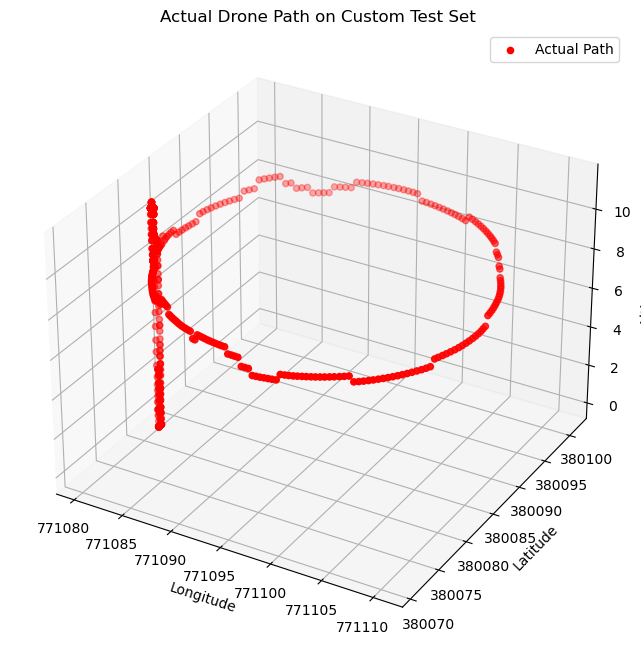

In [25]:
# Load the custom test dataset
test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

df_test_custom=df_test_custom[features]

# Preprocess 'OSD.flyTime' column in the test dataset
df_test_custom['OSD.flyTime'] = df_test_custom['OSD.flyTime'].apply(time_to_seconds)

# Convert latitude and longitude to UTM coordinates
def convert_to_utm(row):
    utm_x, utm_y, _, _ = utm.from_latlon(row['OSD.latitude'], row['OSD.longitude'])
    return pd.Series([utm_x, utm_y])

df_test_custom[['OSD.latitude', 'OSD.longitude']] = df_test_custom.apply(convert_to_utm, axis=1)



# Create a 3D plot for the actual drone path on custom test set
fig_actual_custom = plt.figure(figsize=(12, 8))
ax_actual_custom = fig_actual_custom.add_subplot(111, projection='3d')
ax_actual_custom.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.height [ft]'], c='red', marker='o', label='Actual Path')
ax_actual_custom.set_xlabel('Longitude')
ax_actual_custom.set_ylabel('Latitude')
ax_actual_custom.set_zlabel('Altitude (ft)')
ax_actual_custom.set_title('Actual Drone Path on Custom Test Set')
ax_actual_custom.legend()


# Show the actual and predicted path plots on the custom test set
plt.show()


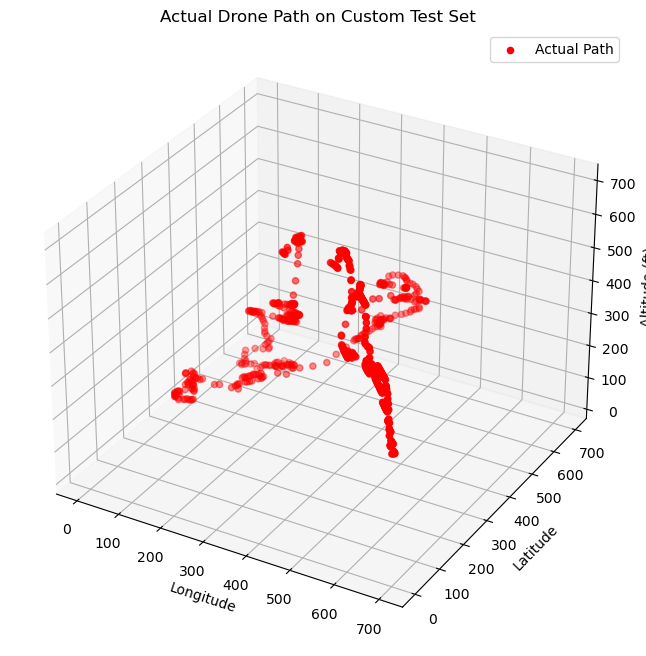

In [23]:
# Load the custom test dataset
test_folder = 'testing'
test_files = [os.path.join(test_folder, file) for file in os.listdir(test_folder) if file.endswith('.csv')]
df_test_custom = pd.concat([pd.read_csv(file) for file in test_files], ignore_index=True)

df_test_custom=df_test_custom[features]

# Preprocess 'OSD.flyTime' column in the test dataset
df_test_custom['OSD.flyTime'] = df_test_custom['OSD.flyTime'].apply(time_to_seconds)

# Convert latitude and longitude to UTM coordinates
def convert_to_utm(row):
    utm_x, utm_y, _, _ = utm.from_latlon(row['OSD.latitude'], row['OSD.longitude'])
    return pd.Series([utm_x, utm_y])

df_test_custom[['OSD.latitude', 'OSD.longitude']] = df_test_custom.apply(convert_to_utm, axis=1)



# Apply rank transformation to each selected feature
for feature in df_test_custom.columns:
    df_test_custom[feature] = df_test_custom[feature].rank()

# Create a 3D plot for the actual drone path on custom test set
fig_actual_custom = plt.figure(figsize=(12, 8))
ax_actual_custom = fig_actual_custom.add_subplot(111, projection='3d')
ax_actual_custom.scatter(df_test_custom['OSD.longitude'], df_test_custom['OSD.latitude'], df_test_custom['OSD.height [ft]'], c='red', marker='o', label='Actual Path')
ax_actual_custom.set_xlabel('Longitude')
ax_actual_custom.set_ylabel('Latitude')
ax_actual_custom.set_zlabel('Altitude (ft)')
ax_actual_custom.set_title('Actual Drone Path on Custom Test Set')
ax_actual_custom.legend()


# Show the actual and predicted path plots on the custom test set
plt.show()
